In [10]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [11]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/Merged files/csv/apple/merged_apple_funadmentals_price_macro.csv')

In [12]:
data[40:]

,calendar_quarter,period_end,Price,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
40,Q4 2019,2019-12-28,70.920372,91819000000,22236000000,1.356574,89531000000,3.35,1.643333
41,Q1 2020,2020-03-28,61.560165,58313000000,11249000000,1.324104,78425000000,1.28,1.260000
42,Q2 2020,2020-06-27,88.552193,59685000000,11253000000,1.294954,72282000000,-7.50,0.060000
43,Q3 2020,2020-09-30,112.650452,64698000000,12673000000,1.252714,65339000000,-1.41,0.093333
44,Q4 2020,2020-12-26,129.292603,111439000000,28755000000,1.230080,66224000000,-1.02,0.090000
45,Q1 2021,2021-03-27,119.200340,89584000000,23630000000,1.258146,69178000000,1.76,0.080000
46,Q2 2021,2021-06-26,133.879730,81434000000,21744000000,1.242055,64280000000,12.24,0.070000
47,Q3 2021,2021-09-25,138.524857,83360000000,20551000000,1.219129,63090000000,4.98,0.090000
48,Q4 2021,2021-12-25,174.090134,123945000000,34630000000,1.232595,71932000000,5.72,0.080000
49,Q1 2022,2022-03-26,171.406250,97278000000,25010000000,1.237938,67399000000,4.01,0.120000


In [13]:
#1)rename period_end to ds and Price to y for prophet

data = data.rename(columns={"period_end": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue", "net_income", "ratio assets/libailities", "shareholders_equity", "gdp_growth", "interest_rate"]]


data[40:]

,ds,y,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
40,2019-12-28,70.920372,91819000000,22236000000,1.356574,89531000000,3.35,1.643333
41,2020-03-28,61.560165,58313000000,11249000000,1.324104,78425000000,1.28,1.260000
42,2020-06-27,88.552193,59685000000,11253000000,1.294954,72282000000,-7.50,0.060000
43,2020-09-30,112.650452,64698000000,12673000000,1.252714,65339000000,-1.41,0.093333
44,2020-12-26,129.292603,111439000000,28755000000,1.230080,66224000000,-1.02,0.090000
45,2021-03-27,119.200340,89584000000,23630000000,1.258146,69178000000,1.76,0.080000
46,2021-06-26,133.879730,81434000000,21744000000,1.242055,64280000000,12.24,0.070000
47,2021-09-25,138.524857,83360000000,20551000000,1.219129,63090000000,4.98,0.090000
48,2021-12-25,174.090134,123945000000,34630000000,1.232595,71932000000,5.72,0.080000
49,2022-03-26,171.406250,97278000000,25010000000,1.237938,67399000000,4.01,0.120000


In [14]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 8    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue", "net_income", "ratio assets/libailities", "shareholders_equity", "gdp_growth","interest_rate"]

# ================== PREP ====================
df = data.copy()
df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue", "net_income", "shareholders_equity"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue", "net_income", "shareholders_equity"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["ratio assets/libailities"] = last["ratio assets/libailities"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15353/4292506178.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [15]:
growth_rates

{'revenue': np.float64(0.07419601480296174),
 'net_income': np.float64(0.11209410685874319),
 'shareholders_equity': np.float64(0.013783186805274492),
 'gdp_growth': np.float64(2.3834920634920636),
 'interest_rate': np.float64(1.3291005291005291)}

In [16]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



13:44:47 - cmdstanpy - INFO - Chain [1] start processing
13:44:47 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
59 2024-09-28  207.446036  194.864254  220.417790  231.920639
60 2024-12-28  222.574621  209.243519  235.663552  249.534180
61 2025-03-29  208.023255  195.577204  220.177451  221.587616
62 2025-06-28  223.372788  209.875291  236.446065  204.937408
63 2025-09-30  239.669274  226.727744  252.306783         NaN
64 2025-12-31  222.747820  209.780255  235.849958         NaN
65 2026-03-31  250.856633  237.459309  264.796075         NaN
66 2026-06-30  269.511715  256.363651  282.972802         NaN
67 2026-09-30  283.949522  270.511048  297.192191         NaN
68 2026-12-31  271.720616  258.953751  285.415765         NaN
69 2027-03-31  298.400444  285.497286  311.870830         NaN
70 2027-06-30  320.330832  306.526186  334.565205         NaN


In [17]:
#7) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 7.722770582192757
RMSE: 105.84298970654895
R²: 0.9790849225416426
           ds        yhat  yhat_lower  yhat_upper           y  is_future
59 2024-09-28  207.446036  194.864254  220.417790  231.920639      False
60 2024-12-28  222.574621  209.243519  235.663552  249.534180      False
61 2025-03-29  208.023255  195.577204  220.177451  221.587616      False
62 2025-06-28  223.372788  209.875291  236.446065  204.937408      False
63 2025-09-30  239.669274  226.727744  252.306783         NaN       True
64 2025-12-31  222.747820  209.780255  235.849958         NaN       True
65 2026-03-31  250.856633  237.459309  264.796075         NaN       True
66 2026-06-30  269.511715  256.363651  282.972802         NaN       True
67 2026-09-30  283.949522  270.511048  297.192191         NaN       True
68 2026-12-31  271.720616  258.953751  285.415765         NaN       True
69 2027-03-31  298.400444  285.497286  311.870830         NaN       True
70 2027-06-30  320.330832  306.526186  334.565205    

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_15353/327559522.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


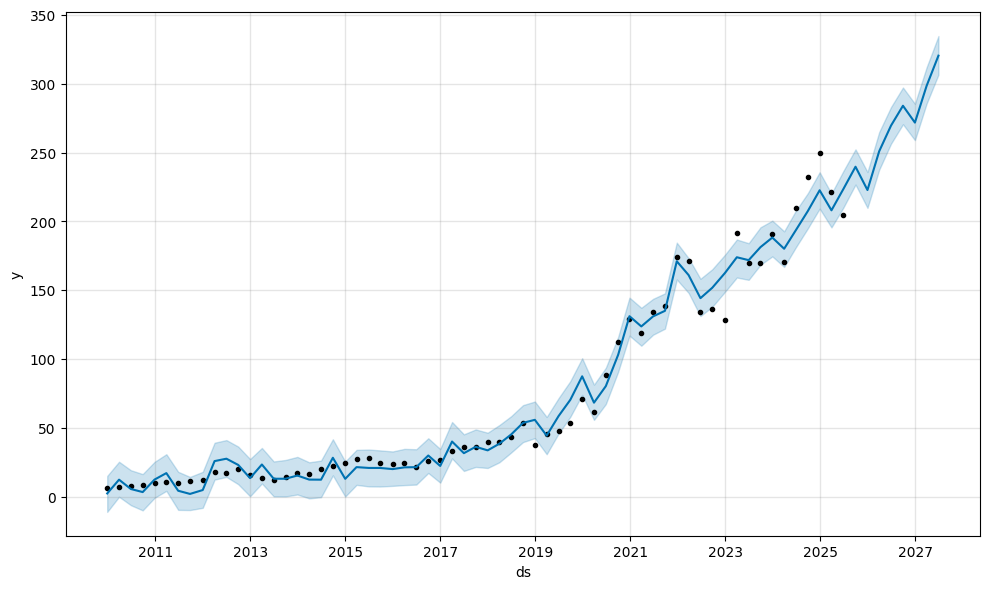

In [18]:
figl = m.plot(forecast)
figl.show()

In [19]:
correlations = data.corr()
correlations

,ds,y,revenue,net_income,ratio assets/libailities,shareholders_equity,gdp_growth,interest_rate
ds,1.000000,0.902000,0.858606,0.795943,-0.904476,-0.296326,0.112132,0.733483
y,0.902000,1.000000,0.803616,0.796313,-0.692570,-0.537808,0.149783,0.750695
revenue,0.858606,0.803616,1.000000,0.968697,-0.800725,-0.172506,0.179239,0.566781
net_income,0.795943,0.796313,0.968697,1.000000,-0.696009,-0.235501,0.230173,0.540376
ratio assets/libailities,-0.904476,-0.692570,-0.800725,-0.696009,1.000000,0.112150,-0.107322,-0.533666
shareholders_equity,-0.296326,-0.537808,-0.172506,-0.235501,0.112150,1.000000,0.015295,-0.333849
gdp_growth,0.112132,0.149783,0.179239,0.230173,-0.107322,0.015295,1.000000,0.086607
interest_rate,0.733483,0.750695,0.566781,0.540376,-0.533666,-0.333849,0.086607,1.000000
